# Setting

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from api import split_expand
from langchain_openai import ChatOpenAI


llm4o = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o',
    temperature=1,
)

llm = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o-mini',
    temperature=1,
)

# 買進賣出需要的手續費
fee = {
    'tax_stock' : 0.003,          # 買進與賣出各0.003
    'tax_future' : 0.00002 * 2,   # 買進與賣出各0.00002
    'fee_stock' : 0.001425 * 2,   # 券商手續費公道價，買進與賣出各0.001425
    'fee_future' : 0.00002 * 2,   # 個家不大相同，以交易稅計算
    'sliding_price' : 0.00001,    # 滑價
}

data = [
    ["2330", "台積電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2454", "聯發科", "tw"],
    ["2382", "廣達", "tw"],
    ["3231", "緯創", "tw"],
    # ["2324","仁寶", "tw"],
    # ["4938", "和碩", "tw"],
    # ["2356","英業達", "tw"],
    # ["2881", "富邦金", "tw"],
    # ["2882", "國泰金", "tw"],
    # ["2412", "中華電", "tw"],
    # ["3045", "台灣大", "tw"],
    # ["6505", "台塑化", "tw"],
    # ["2603", "長榮", "tw"],
    
    ["AAPL", "Apple Inc.", "us"],
    ["GOOGL", "Google", "us"],
    ["MSFT", "Microsoft", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["TSLA", "Tesla", "us"],
    ["NVDA", "Nvidia", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
]

date_ranges = [
    ["20230401", "20240331"],
    ["20230701", "20240630"],
    ["20231001", "20240930"],
]

# env = {
#     "stock_id" : "NVDA",
#     "stock_name" : "Nvidia",
#     "country" : "us",
#     "start_date" : "20230401",
#     "end_date" : "20240331",
# }


In [2]:
from factor import StockFactor
for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])

    stock_factor = StockFactor(env)
    a = stock_factor.get_expand(show_sig=True)
    
    print(stock_factor.get_individual(mode=1))
    

2330 台積電 tw
  20230406 =>   1   1   1   1   1   1   1   1   1   1  -1  -1   1   0   1  -1  -1  -1  -1  -1 
  20230407 =>   1   1  -1   1   1   0   1  -1  -1   1  -1  -1  -1  -1   1   1  -1  -1  -1  -1 
  20230410 =>   1   1   1   1   1   1   1   1   1   1  -1  -1   1   0   1   0   1  -1   1  -1 
  20230411 =>   1   1   1   1   1   0   1   1   1   1  -1   1   1  -1   1  -1  -1  -1   1  -1 
  20230412 =>  -1   1  -1   1   1   0  -1  -1  -1   0  -1  -1   1  -1   1  -1  -1  -1  -1  -1 
  20230413 =>  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1   1  -1   1  -1  -1  -1  -1  -1 
  20230414 =>   1   1   1   1   1   1   1   1   1   1  -1  -1   1   0  -1  -1  -1  -1  -1  -1 
  20230417 =>   1   0   0   1   1   0   0   0   1   1  -1   1   1  -1  -1  -1  -1  -1  -1  -1 
  20230418 =>   1   1   1   1   1   1   1  -1   1   1   0  -1   1   0  -1   0  -1  -1  -1  -1 
  20230419 =>   1   1   1   1   1   1   1   1   1   1  -1   1   1  -1   1   0  -1  -1  -1  -1 
  20230420 =>   1   1   0   1   1   1 

In [3]:
from factor import StockFactor

for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])
    path_folder = "out_stock/GA_factor_" 
    path_out = path_folder + env['start_date'] + "_" + env['end_date'] + "/" + env['stock_id'] + "/"
    path_factors = f"{path_out}/factors.json"
    path_result = f"{path_out}/ev/result.json"

    with open(path_result, 'r') as f:
        result = json.load(f)
        individuals = result['individual']
    
    with open(path_factors , 'r') as f:
        factors = json.load(f)
    i = 0
    for key, value in factors.items():
        if individuals[i] == 1:
            print(key, value)
        i += 1
    print("")

2330 台積電 tw
2 技術領先：新技術如2奈米或1奈米取得突破或吸引客戶。
7 高管展望樂觀：台積電高層對未來營運發表正向預測。
8 外部利多：如地緣政治緩和或政府政策支持。
10 ESG表現出色：永續發展受到肯定，提升公司形象與投資吸引力。
11 營收衰退：月營收或年增率下降，低於市場預期。
13 競爭壓力：三星或英特爾在製程技術上趕超跡象。
14 能源議題：如電力不足、綠電供應問題未解決。
18 法說會保守：高層對未來展望不樂觀，引發投資人憂慮。
20 負面消息：如內部管理問題或市場不利傳言。

2317 鴻海 tw
9 公司管理層強化：蔣尚義加入鴻海，為公司注入新的管理與技術優勢。
11 負面詐騙新聞：有關鴻海股票被詐騙的事件引起投資者疑慮。
12 市場恐慌情緒：股市的整體風險偏好下降，導致鴻海股價跟隨下跌。
13 競爭加劇：立訊等競爭對手加強對蘋果市場的爭奪，可能削弱鴻海的市場份額。
17 宏觀經濟不穩：全球經濟不確定性增加，造成市場恐慌情緒蔓延，拖累股價。
18 外部投資者撤出：部分機構投資者撤出鴻海股份，造成股價下跌。
20 技術發展緩慢：在新技術領域如AI或電動車的進展未達預期，可能對投資者信心產生負面影響。

2454 聯發科 tw
1 產品突破：天璣9300或Wi-Fi 7晶片創下銷售佳績。
6 營收創高：季度或年度營收數據超預期。
10 政策支持：政府政策利多，推動半導體產業發展。
12 外資賣超：法人或自營商減少持股。
14 產品延期或問題：新技術進度延後或效能不及預期。
15 產業負面消息：供應鏈問題或需求減弱的報導。
16 除息影響：除息後股價修正或投資者獲利了結。
17 內部管理問題：如關鍵人員異動或企業政策爭議。
18 法規或政策風險：貿易戰或政府干預影響公司業務。
20 市場利空情緒：股市普遍下跌或投資者轉向其他標的。

2382 廣達 tw
1 AI伺服器需求增長：報導提到廣達在AI伺服器市場的強勢表現。
2 外資目標價調升：外資看好廣達的長期發展，調高目標價。
4 重大訂單簽約：與國際大廠的合作協議帶來利多消息。
5 市場情緒樂觀：AI相關股普遍上漲，帶動廣達跟隨漲勢。
6 季度財報亮眼：公布優於預期的營收或獲利數據。
9 大規模股東活動：如旺年會吸引市場關注並提振信心。
15 財報低於預期：營收或獲利表現不如市場預期。
1

# Factor

In [ ]:
from factor import StockFactor

for stock in data:
    for date_range in date_ranges[1:]:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
        }
        print(env['stock_id'], env['stock_name'], env['country'], env['start_date'], env['end_date'])

        stock_factor = StockFactor(env)
        
        stock_factor.generate_factors(llm4o)
        stock_factor.expand_factors(llm_factors=llm)
        train_datarange, test_datarange = stock_factor.split_exp()

        re_run = True # 是否重新訓練，True:刪除原有資料
        # mode = 0
        # df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        # display(df)
        mode = 1
        df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)

        stock_factor.plot_acumulated_return()

## 顯示所有

In [18]:

import os
import json
import pandas as pd

for date_r in  date_ranges:
    env = {
        "start_date": date_r[0],
        "end_date": date_r[1],
    }

    path_out = f"out_stock/GA_factor_{env['start_date']}_{env['end_date']}/"
    skip_files = {"ac","factors_eng.json", "factors.json", "old_expand", ".DS_Store", "factors.json", "factors1.json", "embeddings.json", "expand.json", "expand1.json", "expand2.json", "clustered_summaries.json"}

    results = []
    index = []

    for folder in os.listdir(path_out):
        if folder in skip_files:
            continue
        folder_path = os.path.join(path_out, folder)
        for file in os.listdir(folder_path):
            if file in skip_files:
                continue
            path = os.path.join(folder_path, file, "result.json")
            with open(path, 'r') as f:
                json_data = json.load(f)
            results.append(json_data['test'])
            index.append(f"{folder}_{file}")

    df = pd.DataFrame(results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                        'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱

    # 計算平均值
    average_row = df[['accuracy', 'precision', 'ev', 'precision_ev']].replace('%', '', regex=True).astype(float).mean()
    df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected = df.loc[:, selected_columns]
    df_sorted = df_selected.sort_index()

    display(df_sorted)
    display(average_row)

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,53.85%,64.29%,0.011392,0.017428,26,9,5,5,7
2330_ev,51.92%,47.83%,0.001448,0.000720,52,22,24,5,1
2382_ev,54.90%,51.22%,0.000641,-0.001264,51,21,20,7,3
2454_ev,51.85%,45.95%,0.005052,0.003664,54,17,20,11,6
3231_ev,43.64%,43.40%,-0.002929,-0.003511,55,23,30,1,1
AAPL_ev,47.54%,43.33%,-0.000280,0.000042,61,13,17,16,15
AMZN_ev,51.79%,63.33%,0.000410,0.002475,56,19,11,10,16
GOOGL_ev,42.37%,53.85%,-0.000196,0.001683,59,7,6,18,28
MSFT_ev,45.00%,46.67%,-0.001703,-0.000901,60,21,24,6,9
NVDA_ev,51.67%,57.14%,-0.000706,0.001846,60,28,21,3,8


accuracy        0.495794
precision       0.503054
ev              0.001268
precision_ev    0.001789
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,44.90%,40.62%,0.003611,0.004776,49,13,19,9,8
2330_ev,62.30%,57.45%,0.004595,0.003718,61,27,20,11,3
2382_ev,39.13%,50.00%,-0.003024,-0.000575,23,5,5,4,9
2454_ev,50.91%,47.62%,0.003373,0.001672,55,20,22,8,5
3231_ev,38.98%,28.89%,-0.000121,-0.003921,59,13,32,10,4
AAPL_ev,50.79%,46.81%,-0.000982,-0.000564,63,22,25,10,6
AMZN_ev,50.79%,51.85%,-0.000320,-0.000309,63,28,26,4,5
GOOGL_ev,33.33%,52.38%,-0.002690,0.000409,63,11,10,10,32
MSFT_ev,61.90%,64.00%,0.000180,0.000144,63,32,18,7,6
NVDA_ev,46.77%,51.11%,-0.002141,-0.001792,62,23,22,6,11


accuracy        0.480929
precision       0.468847
ev              0.000015
precision_ev   -0.000523
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,62.50%,57.69%,0.006835,0.005697,56,15,11,20,10
2330_ev,56.45%,53.19%,0.003997,0.003165,62,25,22,10,5
2382_ev,64.71%,64.71%,0.009490,0.009058,51,11,6,22,12
2454_ev,54.00%,46.15%,0.004480,0.005279,50,12,14,15,9
3231_ev,53.33%,0.00%,-0.000959,0.000000,60,0,5,32,23
AAPL_ev,54.69%,61.54%,-0.000777,0.000695,64,24,15,11,14
AMZN_ev,42.86%,39.02%,-0.001395,-0.002127,63,16,25,11,11
GOOGL_ev,53.97%,51.85%,0.000175,-0.002557,63,14,13,20,16
MSFT_ev,47.54%,45.95%,0.000158,-0.001345,61,17,20,12,12
NVDA_ev,50.79%,50.00%,-0.001655,-0.002591,63,18,18,14,13


accuracy        0.544457
precision       0.496886
ev              0.001991
precision_ev    0.002279
dtype: float64

2330 台積電 tw


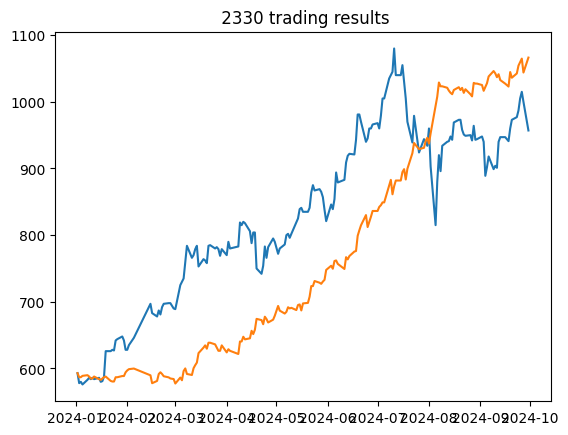

2317 鴻海 tw


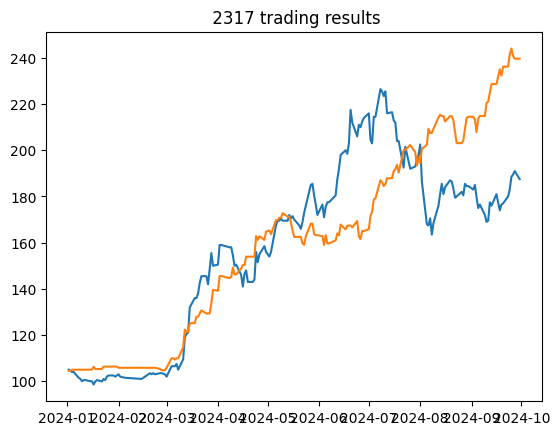

2454 聯發科 tw


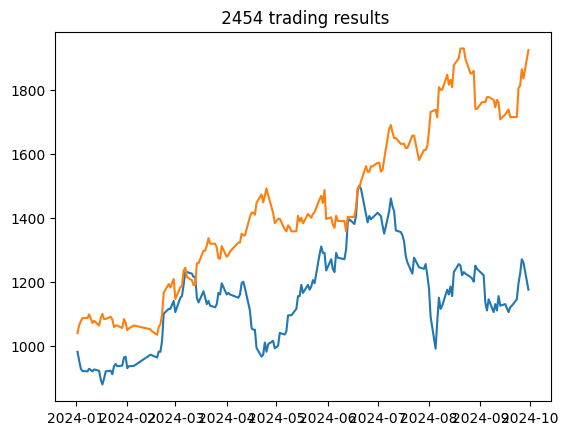

2382 廣達 tw


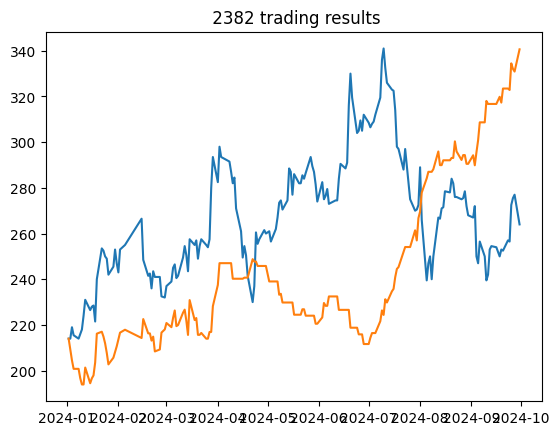

3231 緯創 tw


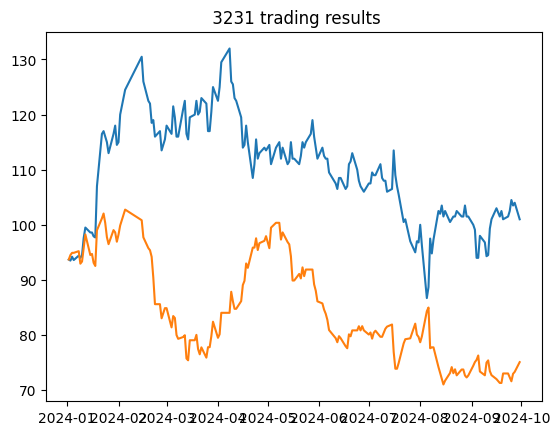

AAPL Apple Inc. us


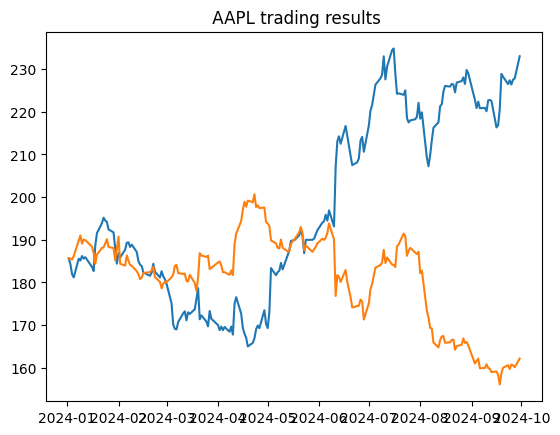

GOOGL Google us


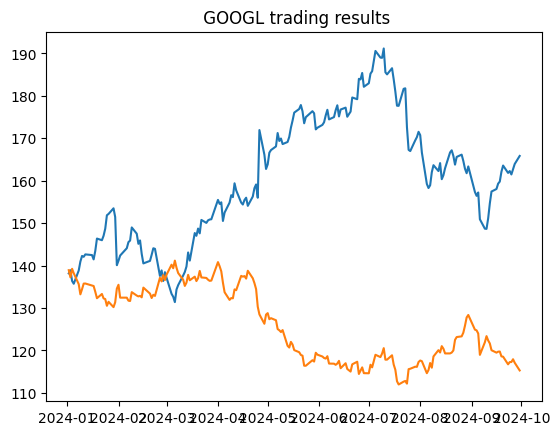

MSFT Microsoft us


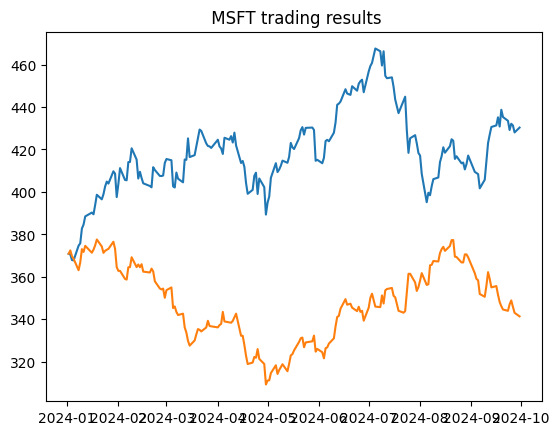

AMZN Amazon inc. us


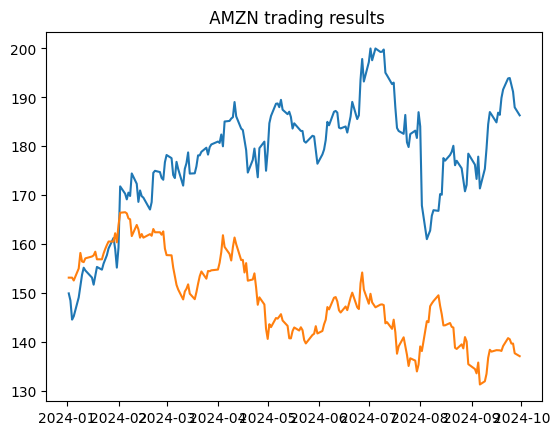

TSLA Tesla us


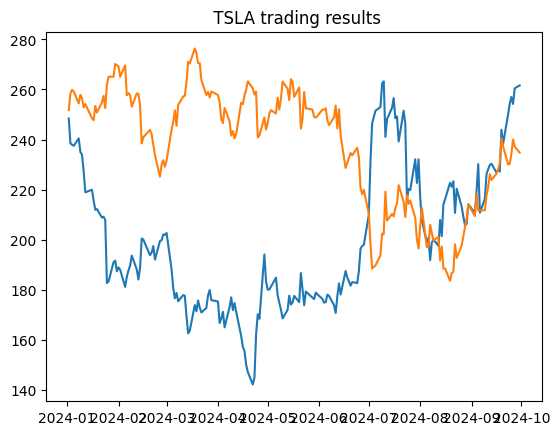

NVDA Nvidia us


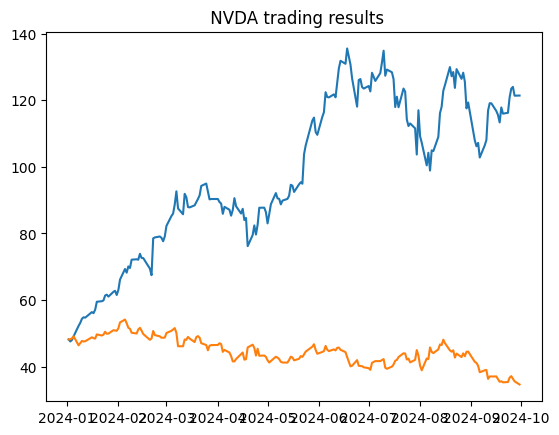

In [19]:
for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])
    stock_factor = StockFactor(env)
    stock_factor.plot_acumulated_return(date_ranges=date_ranges)

# Factor embedding

In [ ]:
from factor_embd import FactorEmb

for stock in data:
    for date_r in  date_ranges:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date": date_r[0],
            "end_date": date_r[1],
        }

        print(env['stock_id'], env['stock_name'], env['country'])


        factor_embd = FactorEmb(env)
        factor_embd.generate_factors(llm4o)
        factor_embd.expand_factors(llm_factors=llm)
        train_datarange, test_datarange = factor_embd.split_exp()

        re_run = False # 是否重新訓練，True:刪除原有資料
        mode = 0
        df = factor_embd.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)
        mode = 1
        df = factor_embd.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)

        factor_embd.plot_acumulated_return()


## 顯示所有

In [20]:
import os
import json
import pandas as pd

for date_r in  date_ranges:
    env = {
        "start_date": date_r[0],
        "end_date": date_r[1],
    }

    path_out = f"out_stock/Embd_{env['start_date']}_{env['end_date']}/"
    skip_files = {"ac","factors_eng.json", "factors.json", "old_expand", ".DS_Store", "factors.json", "factors1.json", "embeddings.json", "expand.json", "expand1.json", "expand2.json", "clustered_summaries.json"}

    results = []
    index = []

    for folder in os.listdir(path_out):
        if folder in skip_files:
            continue
        folder_path = os.path.join(path_out, folder)
        for file in os.listdir(folder_path):
            if file in skip_files:
                continue
            path = os.path.join(folder_path, file, "result.json")
            with open(path, 'r') as f:
                json_data = json.load(f)

            results.append(json_data['test'])
            index.append(f"{folder}_{file}")

    df = pd.DataFrame(results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                        'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱

    # 計算平均值
    average_row = df[['accuracy', 'precision', 'ev', 'precision_ev']].replace('%', '', regex=True).astype(float).mean()
    df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected = df.loc[:, selected_columns]
    df_sorted = df_selected.sort_index()

    display(df_sorted)
    display(average_row)

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,47.27%,47.06%,0.003844,0.003989,55,24,27,2,2
2330_ev,55.56%,48.84%,0.001840,0.000877,54,21,22,9,2
2382_ev,48.21%,48.15%,-0.000266,-0.000734,56,26,28,1,1
2454_ev,51.02%,60.00%,0.003264,0.018223,49,3,2,22,22
3231_ev,42.86%,42.59%,-0.003028,-0.003603,56,23,31,1,1
AAPL_ev,51.67%,46.67%,0.000030,0.000191,60,14,16,17,13
AMZN_ev,58.33%,61.22%,0.002127,0.002495,60,30,19,5,6
GOOGL_ev,46.67%,60.00%,0.000616,0.002773,60,9,6,19,26
MSFT_ev,46.67%,0.00%,-0.001208,0.000000,60,0,2,28,30
NVDA_ev,51.72%,55.32%,-0.001179,0.001215,58,26,21,4,7


accuracy        0.502291
precision       0.465012
ev              0.000637
precision_ev    0.002203
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,50.00%,50.00%,0.004870,0.005682,52,20,20,6,6
2330_ev,57.38%,55.56%,0.003375,0.003820,61,20,16,15,10
2382_ev,41.67%,42.86%,-0.002021,-0.001874,60,24,32,1,3
2454_ev,49.18%,46.94%,0.002639,0.001166,61,23,26,7,5
3231_ev,32.20%,27.78%,-0.004169,-0.005881,59,15,39,4,1
AAPL_ev,51.61%,48.00%,-0.000749,-0.000308,62,24,26,8,4
AMZN_ev,49.21%,50.94%,-0.000629,-0.000498,63,27,26,4,6
GOOGL_ev,57.14%,66.67%,0.001097,0.002664,63,32,16,4,11
MSFT_ev,59.26%,63.33%,0.000896,0.000148,54,19,11,13,11
NVDA_ev,40.98%,46.51%,-0.003350,-0.003102,61,20,23,5,13


accuracy        0.488921
precision       0.489622
ev             -0.000002
precision_ev   -0.000231
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,48.39%,45.10%,0.002523,0.000597,62,23,28,7,4
2330_ev,53.97%,52.17%,0.004052,0.003397,63,24,22,10,7
2382_ev,62.50%,0.00%,0.007509,0.000000,24,0,1,15,8
2454_ev,51.85%,44.44%,0.004221,0.006866,54,8,10,20,16
3231_ev,43.75%,23.81%,-0.003768,-0.006698,48,5,16,16,11
AAPL_ev,50.00%,56.52%,-0.001011,0.000426,64,26,20,6,12
AMZN_ev,37.70%,37.74%,-0.001791,-0.002251,61,20,33,3,5
GOOGL_ev,55.74%,52.17%,0.000852,-0.001091,61,24,22,10,5
MSFT_ev,55.17%,53.57%,0.000834,-0.000544,58,15,13,17,13
NVDA_ev,51.67%,51.16%,0.001188,-0.000380,60,22,21,9,8


accuracy        0.516865
precision       0.443746
ev              0.001274
precision_ev    0.000307
dtype: float64

2330 台積電 tw


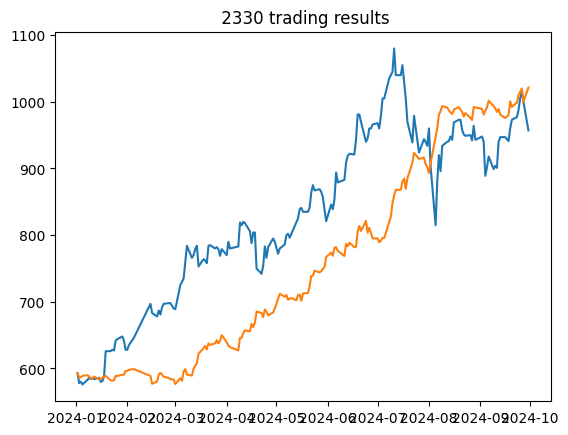

2317 鴻海 tw


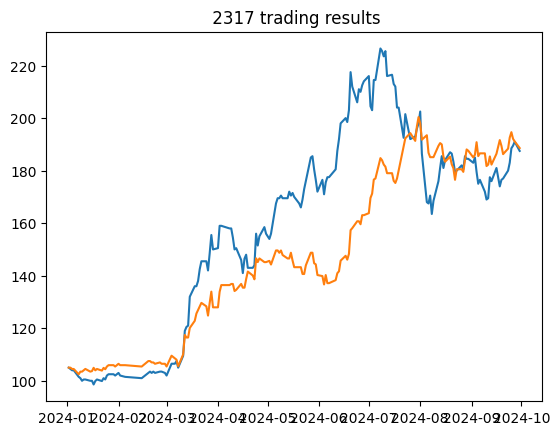

2454 聯發科 tw


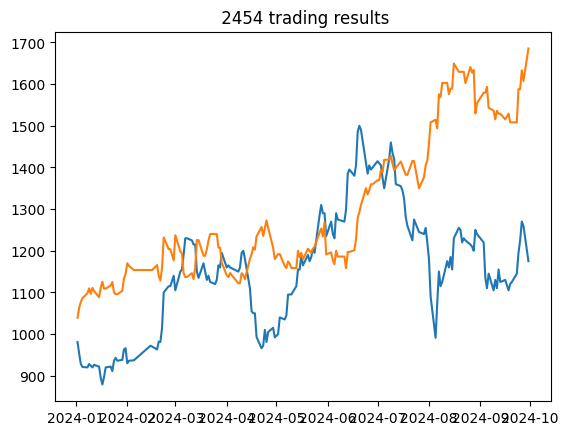

2382 廣達 tw


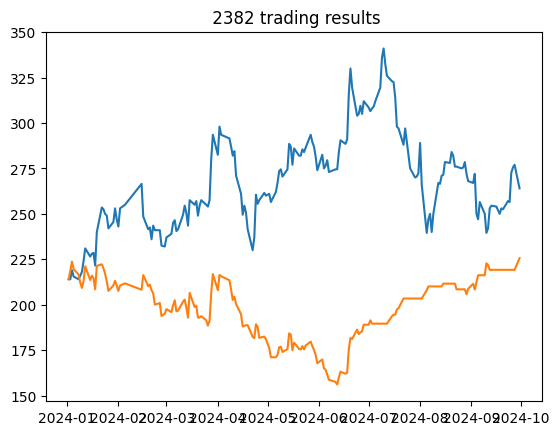

3231 緯創 tw


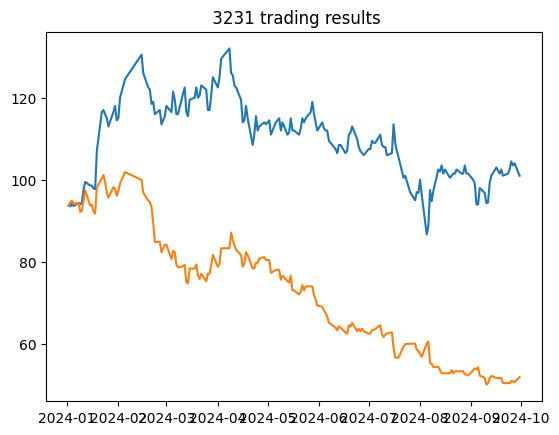

AAPL Apple Inc. us


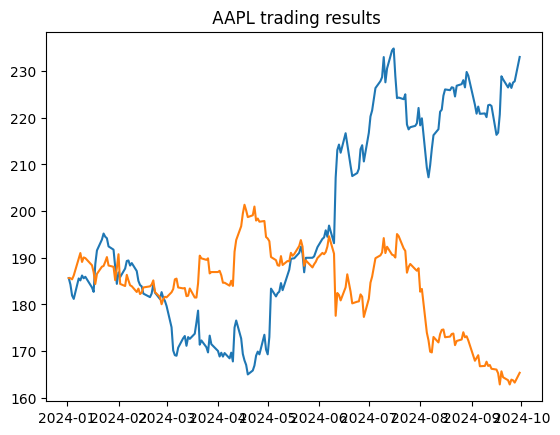

GOOGL Google us


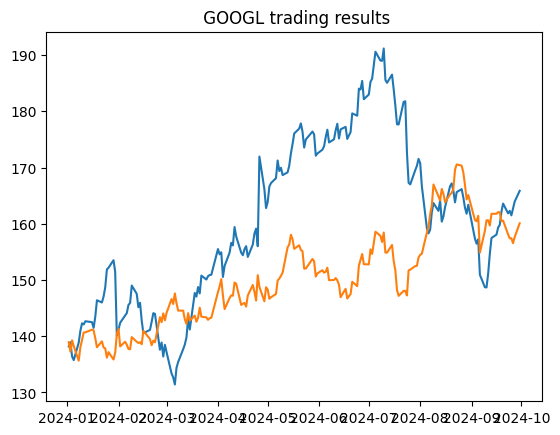

MSFT Microsoft us


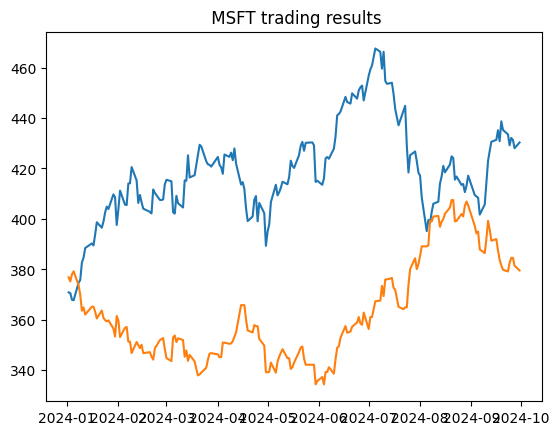

AMZN Amazon inc. us


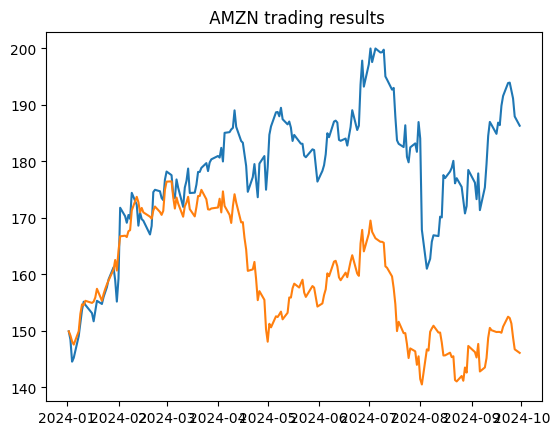

TSLA Tesla us


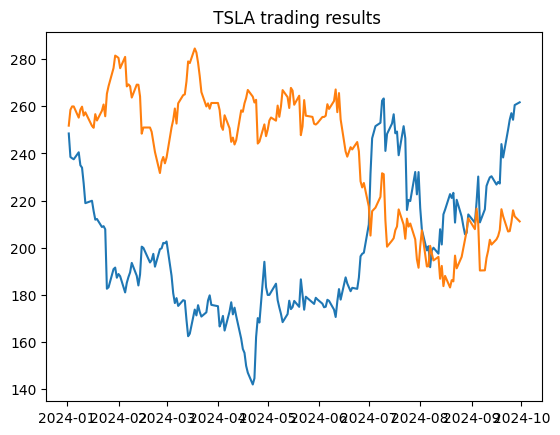

NVDA Nvidia us


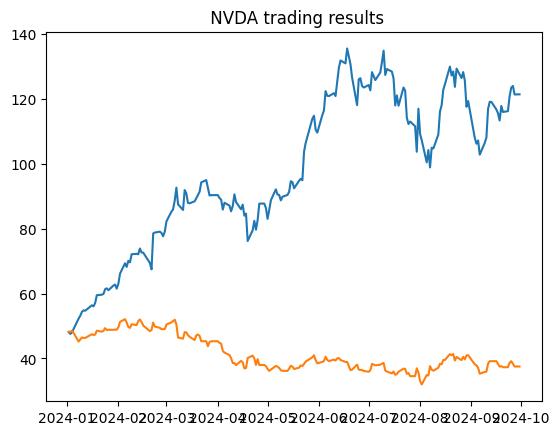

In [10]:
for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])
    factor_embd = FactorEmb(env)
    factor_embd.plot_acumulated_return(date_ranges=date_ranges)